## Lifecycle and Health risk 

### Problem Statement:
 This project aims to predict daily revenue using factors like number of customers, order value, marketing spend, and operational variables. The goal is to identify key drivers that influence revenue and improve business decision-making. By applying machine learning techniques, the model helps in forecasting revenue and optimizing overall performance

### Steps to be followed:
1. Importing the required Libraries
2. Loading the dataset
3. Data Preprocessing
4. Checking Null values
5. Data Wrangling (Filling Null values)
6. Data Visualization
7. Label Encoding
8. Feature Selection (x,y)
9. Train-test split
10. Model Training
11. Model Prediction
12. Accuracy Score
13. Confusion Matrix
14. Classifition Report
15. ROC-curve
16. GridSearch CV 

## Importing Required Libraries


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder , LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             classification_report, f1_score, auc)

## Loading the Dataset 

In [44]:
df=pd.read_csv(r"C:\Users\Admin\Downloads\Lifestyle_and_Health_Risk_Prediction_Synthetic_Dataset.csv")
df

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
0,56.0,67.0,195.0,low,6.1,medium,yes,yes,yes,office_worker,17.6,high
1,69.0,76.0,170.0,high,6.9,high,no,no,no,teacher,26.3,high
2,46.0,106.0,153.0,high,6.6,low,yes,no,no,artist,45.3,high
3,32.0,54.0,186.0,medium,8.5,medium,no,no,no,artist,15.6,low
4,60.0,98.0,195.0,high,8.0,low,no,no,yes,teacher,25.8,high
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,42.0,75.0,187.0,medium,7.2,low,no,no,yes,driver,21.4,low
4996,39.0,86.0,183.0,low,7.4,low,no,no,yes,engineer,25.7,high
4997,48.0,56.0,194.0,none,7.2,high,yes,yes,yes,engineer,14.9,high
4998,34.0,109.0,148.0,medium,9.9,medium,no,no,yes,doctor,49.8,low


## Data Preprocessing

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           4998 non-null   float64
 1   weight        4998 non-null   float64
 2   height        4998 non-null   float64
 3   exercise      4996 non-null   object 
 4   sleep         4997 non-null   float64
 5   sugar_intake  4997 non-null   object 
 6   smoking       4999 non-null   object 
 7   alcohol       4999 non-null   object 
 8   married       4999 non-null   object 
 9   profession    5000 non-null   object 
 10  bmi           5000 non-null   float64
 11  health_risk   5000 non-null   object 
dtypes: float64(5), object(7)
memory usage: 468.9+ KB


In [46]:
df.shape

(5000, 12)

In [47]:
df.columns

Index(['age', 'weight', 'height', 'exercise', 'sleep', 'sugar_intake',
       'smoking', 'alcohol', 'married', 'profession', 'bmi', 'health_risk'],
      dtype='object')

In [48]:
df.describe()

,age,weight,height,sleep,bmi
count,4998.000000,4998.000000,4998.000000,4997.000000,5000.00000
mean,48.804722,77.362345,171.931373,6.997338,26.84388
std,17.909403,18.715082,15.822822,1.433210,8.25249
min,18.000000,45.000000,145.000000,3.000000,11.40000
25%,34.000000,61.000000,158.000000,6.000000,20.30000
50%,49.000000,77.000000,171.500000,7.000000,26.00000
75%,64.000000,94.000000,186.000000,8.000000,32.40000
max,79.000000,109.000000,199.000000,10.000000,51.40000


In [49]:
df.count()

age             4998
weight          4998
height          4998
exercise        4996
sleep           4997
sugar_intake    4997
smoking         4999
alcohol         4999
married         4999
profession      5000
bmi             5000
health_risk     5000
dtype: int64

In [50]:
df.head()

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
0,56.0,67.0,195.0,low,6.1,medium,yes,yes,yes,office_worker,17.6,high
1,69.0,76.0,170.0,high,6.9,high,no,no,no,teacher,26.3,high
2,46.0,106.0,153.0,high,6.6,low,yes,no,no,artist,45.3,high
3,32.0,54.0,186.0,medium,8.5,medium,no,no,no,artist,15.6,low
4,60.0,98.0,195.0,high,8.0,low,no,no,yes,teacher,25.8,high


In [51]:
df.tail()

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
4995,42.0,75.0,187.0,medium,7.2,low,no,no,yes,driver,21.4,low
4996,39.0,86.0,183.0,low,7.4,low,no,no,yes,engineer,25.7,high
4997,48.0,56.0,194.0,none,7.2,high,yes,yes,yes,engineer,14.9,high
4998,34.0,109.0,148.0,medium,9.9,medium,no,no,yes,doctor,49.8,low
4999,72.0,47.0,149.0,high,6.3,medium,no,no,yes,driver,21.2,low


## Check the missing values 

In [52]:
df.isnull().sum()

age             2
weight          2
height          2
exercise        4
sleep           3
sugar_intake    3
smoking         1
alcohol         1
married         1
profession      0
bmi             0
health_risk     0
dtype: int64

In [53]:
df.isnull().any()

age              True
weight           True
height           True
exercise         True
sleep            True
sugar_intake     True
smoking          True
alcohol          True
married          True
profession      False
bmi             False
health_risk     False
dtype: bool

## Fill the missing values 

In [54]:
#for numeric columns 
df['age']=df['age' ].fillna(df['age' ].mean())
df['weight']=df['weight'].fillna(df['weight'].median())
df['height']=df['height'].fillna(df['height'].median())

df['sleep']=df['sleep'].fillna(df['sleep'].median())

In [55]:
# for catogerical 
df['smoking']=df['smoking'].fillna(df['smoking'].mode()[0])
df['exericse']=df['exercise'].fillna(df['exercise'].mode()[0])
df['alcohol  ']=df['alcohol'].fillna(df['alcohol'].mode()[0])
df['married']=df['married'].fillna(df['married'].mode()[0])

In [56]:
df.drop(['sugar_intake'],axis=1,inplace=True)

In [57]:
df.isnull().sum()

age            0
weight         0
height         0
exercise       4
sleep          0
smoking        0
alcohol        1
married        0
profession     0
bmi            0
health_risk    0
exericse       0
alcohol        0
dtype: int64

In [58]:

df['exercise']=df['exercise'].fillna(df['exercise'].mode()[0])
df['alcohol']=df['alcohol'].fillna(df['alcohol'].mode()[0])


In [59]:
df.isnull().sum()

age            0
weight         0
height         0
exercise       0
sleep          0
smoking        0
alcohol        0
married        0
profession     0
bmi            0
health_risk    0
exericse       0
alcohol        0
dtype: int64

In [60]:
df['age'].unique()[:20]
df['exercise'].unique()

array(['low', 'high', 'medium', 'none'], dtype=object)

In [61]:
# remove non-numeric characters
df['age'] = df['age'].astype(str).str.extract('(\d+)', expand=False)

# convert to numeric
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# fill missing
df['age'].fillna(df['age'].median())

0       56
1       69
2       46
3       32
4       60
        ..
4995    42
4996    39
4997    48
4998    34
4999    72
Name: age, Length: 5000, dtype: int64

In [62]:
df['exercise'].value_counts()

exercise
medium    1988
low       1270
high      1000
none       742
Name: count, dtype: int64

In [63]:
df.dtypes
df.isnull().sum()

age            0
weight         0
height         0
exercise       0
sleep          0
smoking        0
alcohol        0
married        0
profession     0
bmi            0
health_risk    0
exericse       0
alcohol        0
dtype: int64

In [64]:
df[['age','exercise']].head(10)
df['age'].unique()[:15]
df['exercise'].unique()
df.dtypes

age              int64
weight         float64
height         float64
exercise        object
sleep          float64
smoking         object
alcohol         object
married         object
profession      object
bmi            float64
health_risk     object
exericse        object
alcohol         object
dtype: object

In [65]:
df.isnull().sum()

age            0
weight         0
height         0
exercise       0
sleep          0
smoking        0
alcohol        0
married        0
profession     0
bmi            0
health_risk    0
exericse       0
alcohol        0
dtype: int64

## Data Visualization / EDA 

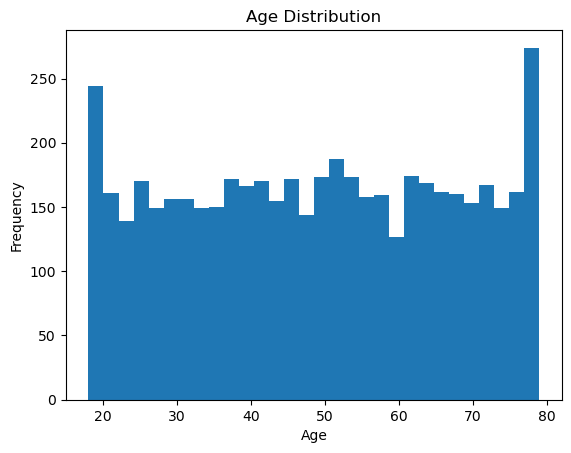

In [66]:
plt.hist(df['age'], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

### The histogram shows the distribution of age, highlighting concentration, spread, and possible skewness in the data.

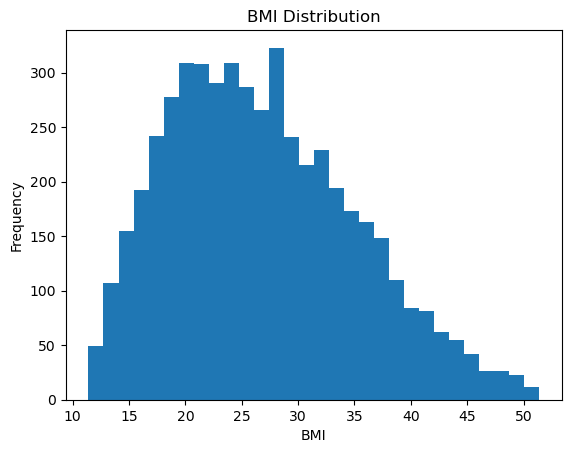

In [67]:
plt.hist(df['bmi'], bins=30)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

### The BMI distribution shows most individuals fall within a central range, with slight variation and possible outliers 

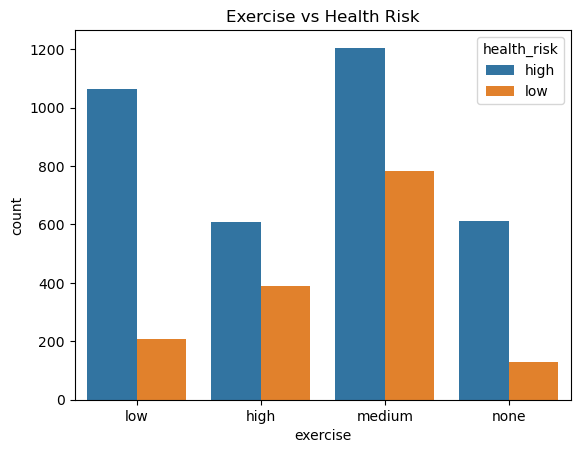

In [68]:
sns.countplot(x='exercise', hue='health_risk', data=df)
plt.title("Exercise vs Health Risk")
plt.show()

### Higher exercise levels are associated with lower health risk, showing a strong negative relationship

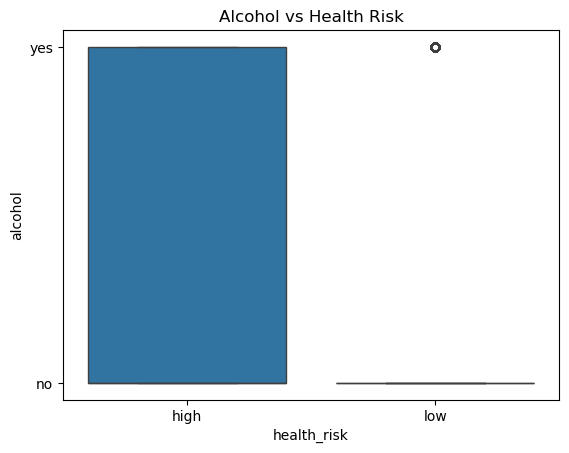

In [69]:
sns.boxplot(x='health_risk', y='alcohol', data=df)
plt.title("Alcohol vs Health Risk")
plt.show()

### Higher alcohol consumption is linked to increased health risk, with noticeable variation and outliers

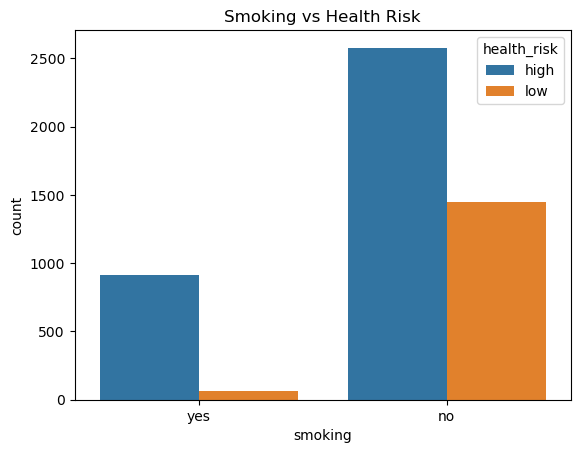

In [70]:
sns.countplot(x='smoking', hue='health_risk', data=df)
plt.title("Smoking vs Health Risk")
plt.show()

### Smoking is associated with higher health risk, indicating a strong negative impact on health

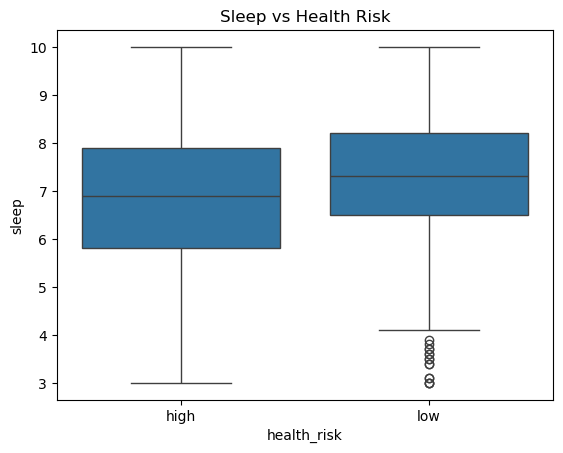

In [71]:
sns.boxplot(x='health_risk', y='sleep', data=df)
plt.title("Sleep vs Health Risk")
plt.show()

### Lower sleep duration is associated with higher health risk, indicating sleep plays an important role in health

In [72]:
cat_cols=df.select_dtypes(include='object')

## Label Encoding

In [73]:
from sklearn.preprocessing import LabelEncoder
label=LabelEncoder()
for c in cat_cols:
    df[c]=label.fit_transform(df[c])

## Feature Selection (x, y)

In [74]:
x=df.drop('health_risk',axis=1)
y=df['health_risk']

## Train-Test Split

In [75]:
from sklearn.model_selection import train_test_split
x_train ,x_test, y_train ,y_test= train_test_split (x,y,test_size=0.2,random_state=42)

## Model Training

In [76]:
lor=LogisticRegression()
lor.fit(x_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

## Model Prediction 

In [77]:
y_pred=lor.predict(x_test)

## Accuracy Score 

In [78]:
accuracy_score(y_test,y_pred)

0.846

## Classification Report 

In [79]:
print(classification_report(y_test,y_pred))  

              precision    recall  f1-score   support

           0       0.87      0.92      0.89       708
           1       0.77      0.67      0.72       292

    accuracy                           0.85      1000
   macro avg       0.82      0.80      0.81      1000
weighted avg       0.84      0.85      0.84      1000



## confusion matrix

In [80]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[649  59]
 [ 95 197]]


## ROC-Curve

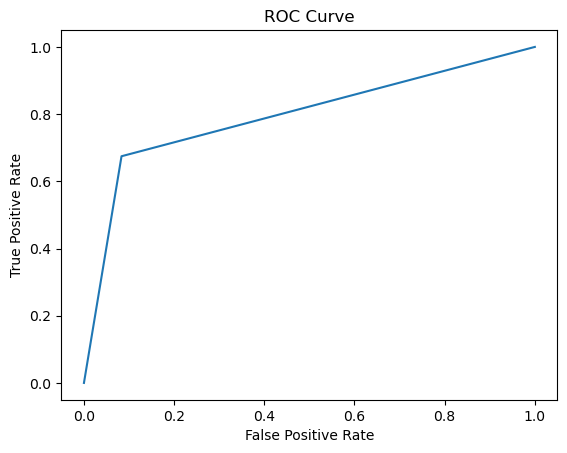

In [89]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

## Gridsearch CV

In [92]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    cv=5,
                    scoring='accuracy')

grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}


In [93]:
best_model = grid.best_estimator_

y_pred = best_model.predict(x_test)